# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuratulainAzhar22/flyrank-ml-work/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

**Abstract**

This project investigates whether current search-performance signals can be used to prioritize content with potential CTR opportunities. Using anonymized FlyRank warehouse data, I examined Google Search Console impressions, clicks, and average search position and built a position-adjusted CTR baseline that ranks pages with meaningful search visibility but below-benchmark CTR. A Decision Tree model was then used to reproduce this prioritization rule and evaluated using both the original split and a client-grouped split. The model achieved 98.9% accuracy and 96.76% macro F1 on the original evaluation, and 99.79% accuracy and 98.24% macro F1 on the client-grouped evaluation. These results show that the model can reproduce the prioritization rule consistently across held-out clients, but they should not be interpreted as proof of future SEO performance because the target is derived from the same current-period signals used as model inputs. The final output is therefore best treated as a transparent decision-support system for identifying pages that warrant human review.

## 1. Question

*The research question and the decision it supports.*\
Research question

**Can current search-performance signals be used to prioritize content that shows a measurable CTR opportunity, while avoiding a simple global CTR threshold?**

Decision supported

The goal is to produce a ranked review queue for content teams. The queue highlights pages with meaningful search visibility and CTR that is weak relative to their observed search position.

This is a decision-support problem, not a claim that the model predicts future traffic or that changing a page will cause improvement.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data release and scope

I used the public-safe FlyRank internship warehouse release and worked primarily with the fact_content_daily_performance table.

For the baseline analysis, I used the March 2026 reporting window. The analysis required usable Google Search Console data, positive impressions, and a non-null average position.

Rows without usable GSC data were excluded because CTR and position-based opportunity could not be measured reliably for those rows.

Client and content identifiers were retained only for grouping, traceability within the anonymized dataset, and validation. They were not used as model features.

The final month was treated as a sealed evaluation period rather than being used to develop the label logic.

The March workflow we previously used explicitly filtered to gsc_data_available IS TRUE, positive impressions, and non-null average position.

In [1]:
print("Data window: March 2026")
print("Required fields:")
print("- gsc_data_available")
print("- gsc_impressions")
print("- gsc_clicks")
print("- gsc_avg_position")

Data window: March 2026
Required fields:
- gsc_data_available
- gsc_impressions
- gsc_clicks
- gsc_avg_position


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Features

The final model uses three current-period search signals:

gsc_impressions
gsc_clicks
gsc_avg_position

CTR is calculated as clicks divided by impressions.

Baseline

The baseline first divides pages into four position groups: 1–3, 4–10, 11–20, and 21+. It calculates an observed CTR benchmark for each group.

A row receives higher priority when its CTR is below the benchmark for its position and it has meaningful impression volume.

Label

The classification target follows the baseline action rule. This means the model is learning to reproduce the decision rule rather than independently predicting a future business outcome.

Model

I used a Decision Tree classifier with max_depth=5. This was chosen because it provides a simple, interpretable model that can be inspected rather than an unnecessarily complex model.

Validation

I first measured the model using the earlier train/test design. I then evaluated it using a client-grouped split so that the same client could not appear in both training and test sets.

Leakage checks

Client and content identifiers were excluded from model features. I also checked that baseline scores, reason codes, actions, trend fields, and other target-derived fields were not included as model inputs.

The main methodological limitation is that the target is derived from the same current-period signals supplied to the model. Therefore, model performance should be interpreted as successful reproduction of the prioritization rule, not independent evidence of future SEO performance.

The actual feature list from our audit was exactly those three fields, with no identifier leakage.

And the Decision Tree used max_depth=5

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Results

The model reproduced the baseline classification very accurately.

Under the original Week-5 evaluation, the model measured 98.9% accuracy and 96.76% macro F1.

Under the client-grouped evaluation, accuracy was 99.79% and macro F1 was 98.24%.

The grouped split contained 31 training clients and 8 test clients, with zero client overlap.

These results show that the Decision Tree can reproduce the rule consistently across held-out clients. They do not show that the model can predict future traffic, rankings, or organic growth.

| Evaluation            | Accuracy | Macro F1 |
| --------------------- | -------: | -------: |
| Original Week-5 split |   0.9890 |   0.9676 |
| Client-grouped split  |   0.9979 |   0.9824 |


In [2]:
import pandas as pd
comparison = pd.DataFrame({
    "Evaluation": [
        "Original Week-5 split",
        "Client-grouped split"
    ],
    "Accuracy": [
        0.9890,
        0.9979
    ],
    "Macro F1": [
        0.9676,
        0.9824
    ]
})

comparison

,Evaluation,Accuracy,Macro F1
0,Original Week-5 split,0.9890,0.9676
1,Client-grouped split,0.9979,0.9824


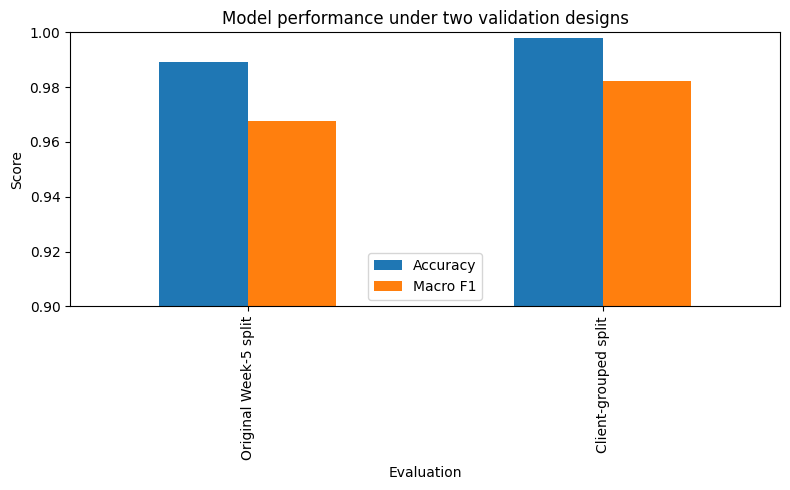

In [3]:
import matplotlib.pyplot as plt

comparison.set_index("Evaluation")[["Accuracy", "Macro F1"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylim(0.9, 1.0)
plt.ylabel("Score")
plt.title("Model performance under two validation designs")
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*


1. The target is derived from the same search-performance signals used as model inputs. Therefore, the high classification scores mainly show that the model can reproduce the prioritization rule.\
2. The analysis does not establish causality. A low CTR does not prove that a content change will increase clicks.\
3. Impression volume is an opportunity signal, not evidence that an intervention will succeed.\
4. Zero CTR observations may reflect measurement, rounding, tracking, or incomplete reporting issues.\
5. The available performance table did not provide a direct content-age or publication-date field for the baseline, so I could not test content freshness as an independent feature.\
6. The grouped evaluation uses held-out clients, but it is still based on a limited evaluation setup and should not be treated as proof of production performance.\
7. The analysis does not measure the causal effect of refreshing titles, updating content, or making other SEO changes.

That last point is especially important because our previous work already questioned whether the reported freshness relationship should be interpreted causally.\
We also explicitly identified the lack of a direct content-age field as a limitation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Action playbook

The ranked queue should be used as a review list rather than an automatic instruction to change content.

Priority 1 — Review high-visibility pages with below-benchmark CTR

Start with pages that have meaningful impressions and CTR below the benchmark for their position group. These pages have both measurable search exposure and an observed CTR gap.

Priority 2 — Validate the measurement before changing content

Check whether zero or unusually low CTR values are genuine before taking action. The top-ranked rows frequently contained zero CTR, so measurement quality should be checked first.

Priority 3 — Review title and snippet relevance

Where the CTR signal is reliable, review whether the search result title and snippet clearly match the query intent and page content.

Priority 4 — Prioritize higher-volume opportunities

When several pages show similar CTR gaps, give earlier review to pages with greater impression volume because they represent more search exposure.

Priority 5 — Re-measure after intervention

Any content change should be followed by a new measurement window. The ranking itself should not be treated as evidence that an intervention caused improvement.

This is consistent with our actual queue: the baseline uses low CTR relative to position plus impressions, and the resulting queue contained 3,611,061 rows.

And our manual review found that many high-ranked pages had zero CTR, which is exactly why we said those should be treated cautiously.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

I would keep this section simple. Your deployed research paper does not need 15 charts.

Use these 4 artifacts:
Artifact 1 — CTR by position bucket

Shows:
| Position | Observed CTR |
| -------- | -----------: |
| 1–3      |     0.003814 |
| 4–10     |     0.003041 |
| 11–20    |     0.003056 |
| 21+      |     0.001262 |

This supports the central idea that CTR should be interpreted relative to position. These are the actual observed values from our baseline analysis

Artifact 2 — Impression-volume buckets
| Impression bucket | Total impressions |
| ----------------- | ----------------: |
| <10               |       535,373,900 |
| 10–99             |       548,147,670 |
| 100–999           |     1,616,094,300 |
| 1000+             |       588,796,530 |

This shows why impression volume is useful as an opportunity/prioritization signal rather than treating every low-CTR row equally.

Artifact 3 — Model validation table

before/after table:
| Validation     | Accuracy | Macro F1 |
| -------------- | -------: | -------: |
| Original split |   98.90% |   96.76% |
| Client-grouped |   99.79% |   98.24% |

Artifact 4 — Top recommendation queue

Show a small public-safe table, for example:
| Rank | Action            | Reason                        | Confidence |
| ---: | ----------------- | ----------------------------- | ---------- |
|    1 | Prioritize review | Below-position CTR / zero CTR | Medium     |
|    2 | Prioritize review | Below-position CTR / zero CTR | Medium     |
|    3 | Prioritize review | Below-position CTR / zero CTR | Medium     |
|    4 | Prioritize review | Below-position CTR / zero CTR | Medium     |
|    5 | Prioritize review | Below-position CTR / zero CTR | Medium     |


**Acknowledgments & data credit**

This work was completed as part of the FlyRank ML internship. The analysis uses the public-safe FlyRank internship warehouse provided for the program. Data and methodology are used for educational and decision-support purposes.


## ML-12 — 5-Minute Demo Outline

**0:00–0:40 — Problem & Research Question**
Introduce the research question: whether current search-performance signals can be used to prioritize content with potential CTR opportunities. Explain that the goal is decision support rather than predicting future SEO performance.

**0:40–1:20 — Data**
Show the anonymized FlyRank warehouse data used for the analysis. Explain the March 2026 analysis window and the main GSC fields: impressions, clicks, and average position.

**1:20–2:10 — Methodology**
Explain the position-adjusted CTR baseline. Show the four position buckets and explain how CTR benchmarks and impression volume were used to prioritize pages.

**2:10–3:10 — Model & Results**
Show the Decision Tree features and the validation results. Compare the original evaluation (98.9% accuracy, 96.76% macro F1) with the client-grouped evaluation (99.79% accuracy, 98.24% macro F1).

**3:10–4:10 — Ranked Recommendations**
Show the ranked action queue and explain how high-visibility pages with below-benchmark CTR are prioritized for human review.

**4:10–4:40 — Limitations**
Explain that the target is derived from the same current-period signals used as model features, so the high scores demonstrate rule reproduction rather than independent future prediction. Also explain that the analysis does not establish causality.

**4:40–5:00 — Takeaway**
Conclude that the workflow provides a transparent, interpretable decision-support system for prioritizing potential CTR opportunities.


## ML-12 — Social-post cut
I built a decision-support workflow for my FlyRank ML Capstone to identify potential CTR opportunities in search performance data.

I used anonymized Google Search Console signals — impressions, clicks, and average position — to build a position-adjusted baseline and a simple Decision Tree model.

The model reproduced the prioritization rule with 98.9% accuracy on the original evaluation and 99.79% accuracy under a client-grouped evaluation.

The most important lesson was methodological: a high model score does not automatically mean strong future prediction when the target is derived from the same signals used as features.

The final output is a ranked review queue that helps prioritize pages for human investigation rather than automatically recommending changes.

/#MachineLearning #DataScience #SEO #Python #FlyRank

## ML-12 — Employer-facing summary
I built an interpretable machine-learning workflow that uses Google Search Console signals to prioritize content with potential CTR opportunities. I developed a position-adjusted baseline, trained a Decision Tree to reproduce the prioritization rule, and evaluated it using both a standard split and a client-grouped validation design. The project strengthened my ability to connect data analysis, machine learning, leakage checking, validation, and practical recommendations into an end-to-end decision-support workflow.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
